In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
from google.colab import files
uploaded = files.upload()

Saving bangladesh_student_performance.csv to bangladesh_student_performance (1).csv


In [5]:
df = pd.read_csv('bangladesh_student_performance.csv')
df.head()

,Student_ID,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result
0,1,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,4.83,4.22,5.00
1,2,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,4.96,4.09,4.77
2,3,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,4.32,4.86,4.62
3,4,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,4.63,3.54,3.75
4,5,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,4.50,4.65,3.46


In [6]:
df.describe

<bound method NDFrame.describe of      Student_ID  Gender  Age    District School_Type  Study_Hours_per_Week  \
0             1    Male   16     Rangpur     Private                    11   
1             2  Female   17    Rajshahi     Private                     7   
2             3    Male   15     Barisal     Private                    27   
3             4    Male   15  Mymensingh     Private                    18   
4             5    Male   15  Mymensingh      Public                    28   
..          ...     ...  ...         ...         ...                   ...   
995         996    Male   15       Dhaka     Private                    17   
996         997    Male   16      Sylhet     Private                     9   
997         998  Female   15      Khulna     Private                     5   
998         999  Female   17  Chattogram     Private                    28   
999        1000    Male   15  Mymensingh     Private                    16   

     Attendance  Parent_Education  Family_Income_BDT Internet_Access  \
0            70          Graduate              49169             Yes   
1            76           Primary              57947              No   
2            63  Higher Secondary              57224             Yes   
3            84           Primary              55865              No   
4            89  Higher Secondary              35553              No   
..          ...               ...                ...             ...   
995          86  Higher Secondary              11129              No   
996          77           Primary              38022              No   
997          82          Graduate              11605              No   
998          70         Secondary              21970             Yes   
999          80          Graduate              53705             Yes   

    Private_Tuition  Previous_GPA  SSC_Result  HSC_Result  
0               Yes          4.83        4.22        5.00  
1                No          4.96        4.09        4.77  
2               Yes          4.32        4.86        4.62  
3                No          4.63        3.54        3.75  
4               Yes          4.50        4.65        3.46  
..              ...           ...         ...         ...  
995              No          3.50        4.41        4.08  
996             Yes          3.71        4.17        3.62  
997             Yes          3.35        4.92        3.29  
998             Yes          4.39        3.57        4.47  
999              No          4.23        4.78        4.20  

[1000 rows x 14 columns]>

In [7]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

(1000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   object 
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   object 
 4   School_Type           1000 non-null   object 
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   object 
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   object 
 10  Private_Tuition       1000 non-null   object 
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
dtypes: float64(3), int64(5), object(6)
memory usage: 109.5+ KB


np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

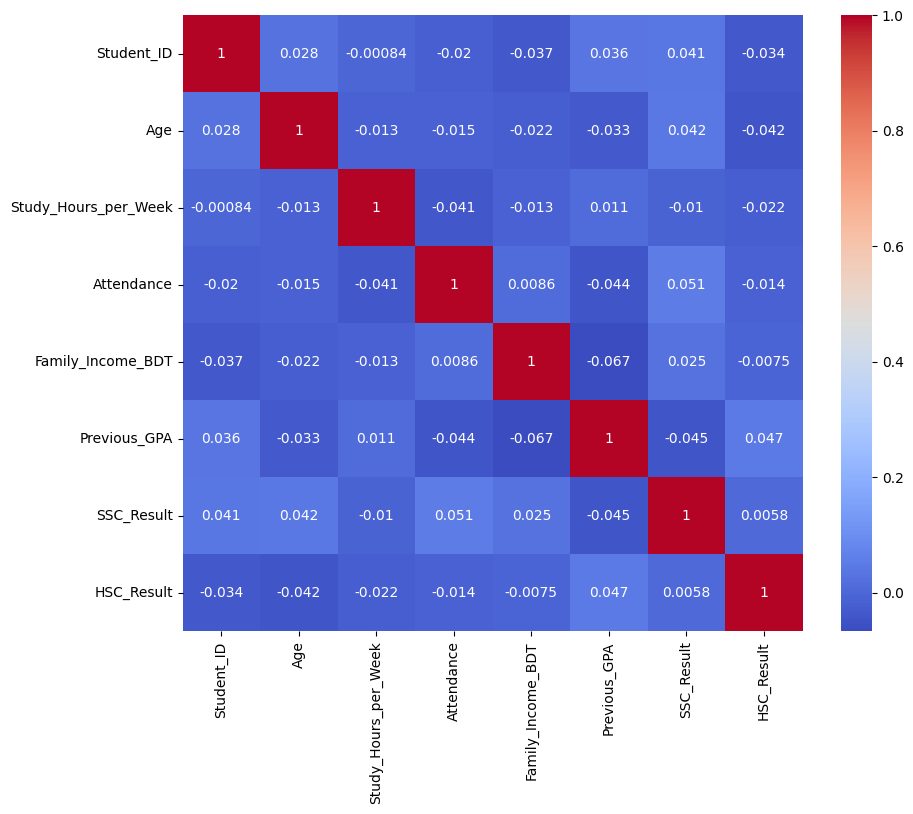

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

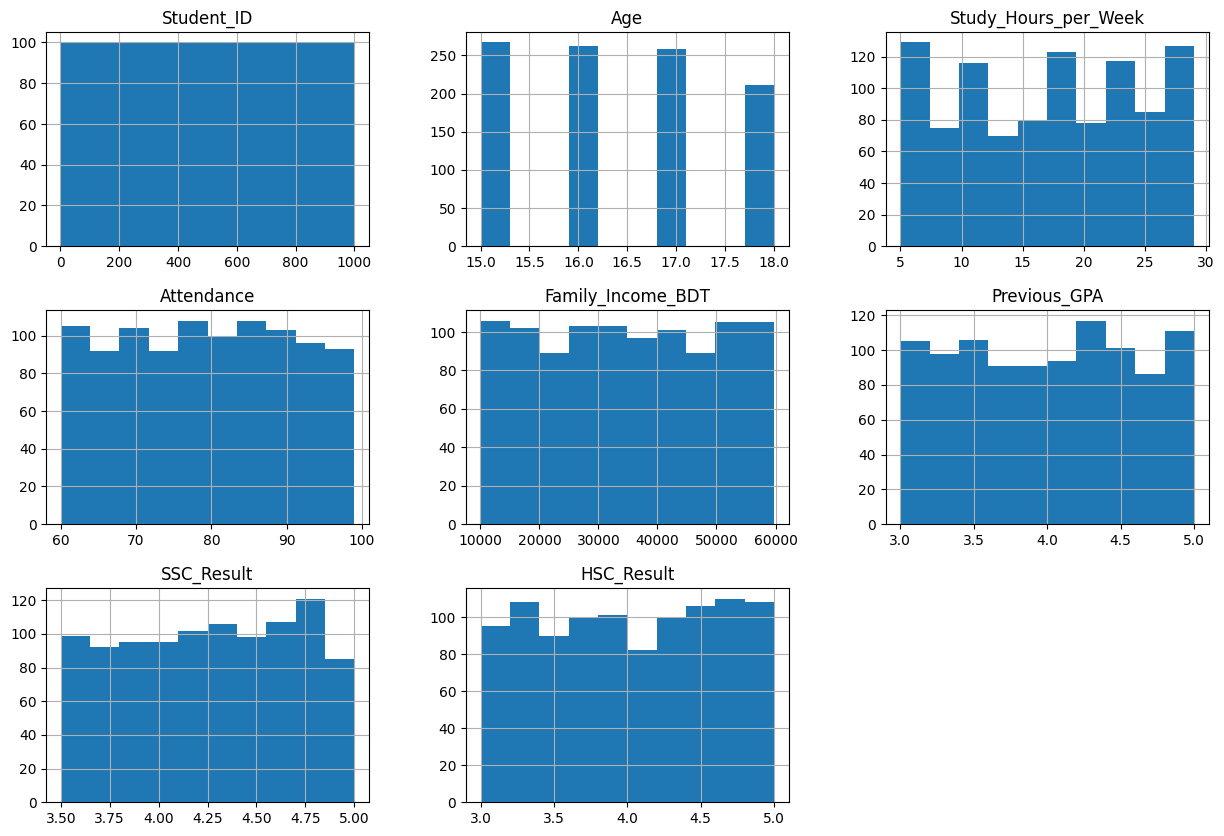

In [13]:
df.hist(figsize=(15,10))
plt.show()

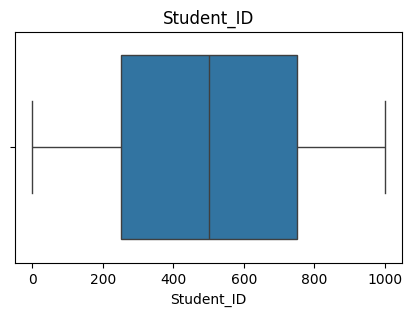

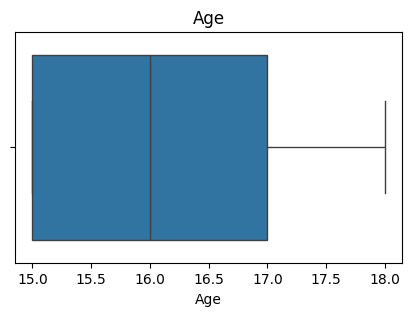

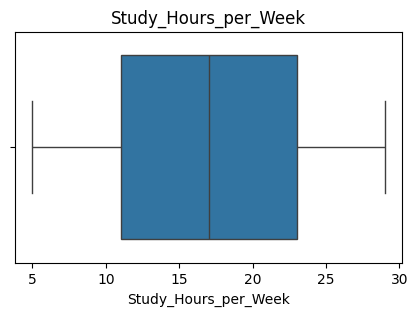

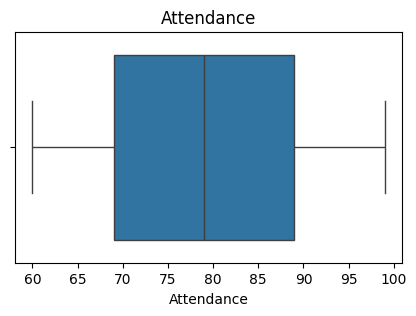

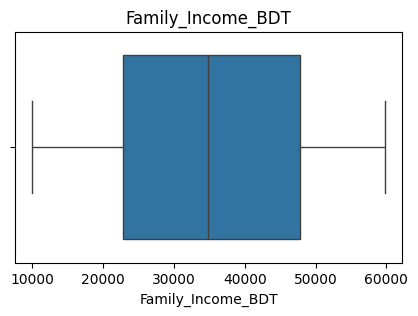

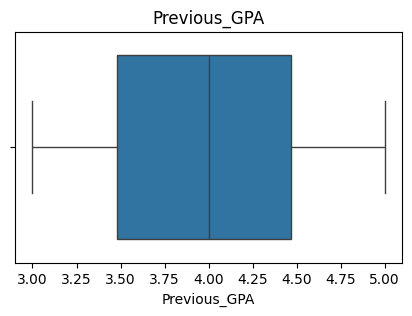

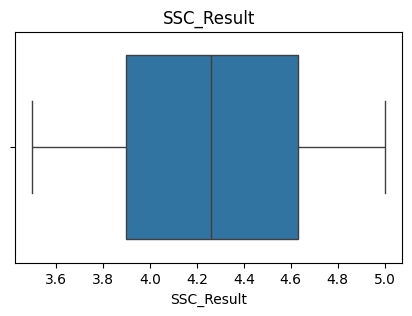

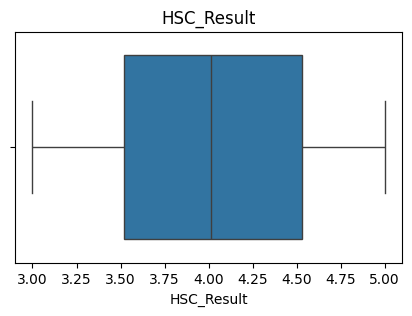

In [14]:
numeric=df.select_dtypes(include=np.number).columns

for col in numeric:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [15]:
def category(row):

    if (
        row['Previous_GPA'] >= 4.7 and
        row['Attendance'] >= 90 and
        row['Study_Hours_per_Week'] >= 25
    ):
        return 'A'

    elif (
        row['Previous_GPA'] >= 3.8 and
        row['Attendance'] >= 75 and
        row['Study_Hours_per_Week'] >= 15
    ):
        return 'B'

    else:
        return 'C'

df['Category'] = df.apply(category, axis=1)

df[['Previous_GPA','Attendance',
    'Study_Hours_per_Week','Category']].head()

,Previous_GPA,Attendance,Study_Hours_per_Week,Category
0,4.83,70,11,C
1,4.96,76,7,C
2,4.32,63,27,C
3,4.63,84,18,B
4,4.50,89,28,B


In [18]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [40]:
X = df.drop(['Category', 'Student_ID'], axis=1)
y = df['Category']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [28]:
svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm.fit(X_train, y_train)

SVC(C=1)

In [29]:
y_pred = svm.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy*100)

Accuracy : 92.5


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.85      0.79      0.82        43
           2       0.94      0.97      0.96       156

    accuracy                           0.93       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.92      0.93      0.92       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


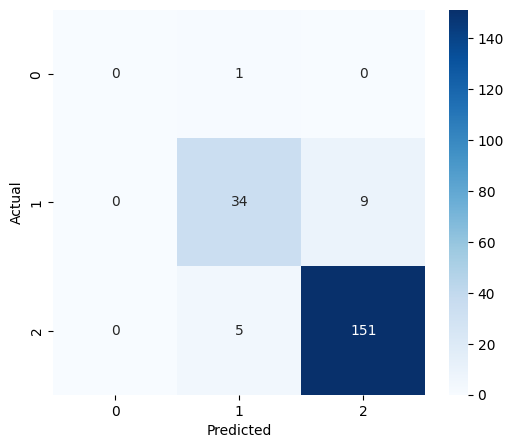

In [38]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [53]:
new_student = pd.DataFrame({

'Gender':[1],
'Age':[18],
'District':[2],
'School_Type':[1],
'Study_Hours_per_Week':[22],
'Attendance':[88],
'Parent_Education':[2],
'Family_Income_BDT':[50000],
'Internet_Access':[1],
'Private_Tuition':[1],
'Previous_GPA':[4.4],
'SSC_Result':[4.5],
'HSC_Result':[4.4]

})

new_student = scaler.transform(new_student)

prediction = svm.predict(new_student)

print("Predicted Category:", prediction)

Predicted Category: [1]


In [44]:
X = df.drop(['Category', 'Student_ID'], axis=1)
y = df['Category']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [47]:
svm = SVC( data
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm.fit(X_train, y_train)

SVC(C=1)

In [48]:
new_student = pd.DataFrame({

'Gender':[1],
'Age':[18],
'District':[2],
'School_Type':[1],
'Study_Hours_per_Week':[22],
'Attendance':[88],
'Parent_Education':[2],
'Family_Income_BDT':[50000],
'Internet_Access':[1],
'Private_Tuition':[1],
'Previous_GPA':[4.4],
'SSC_Result':[4.5],
'HSC_Result':[4.4]

})

new_student_scaled = scaler.transform(new_student)

prediction = svm.predict(new_student_scaled)

print("Predicted Category:", prediction)

Predicted Category: [1]


In [52]:
pickle.dump(svm, open("svm_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [54]:
df.to_csv("student_category.csv", index=False)

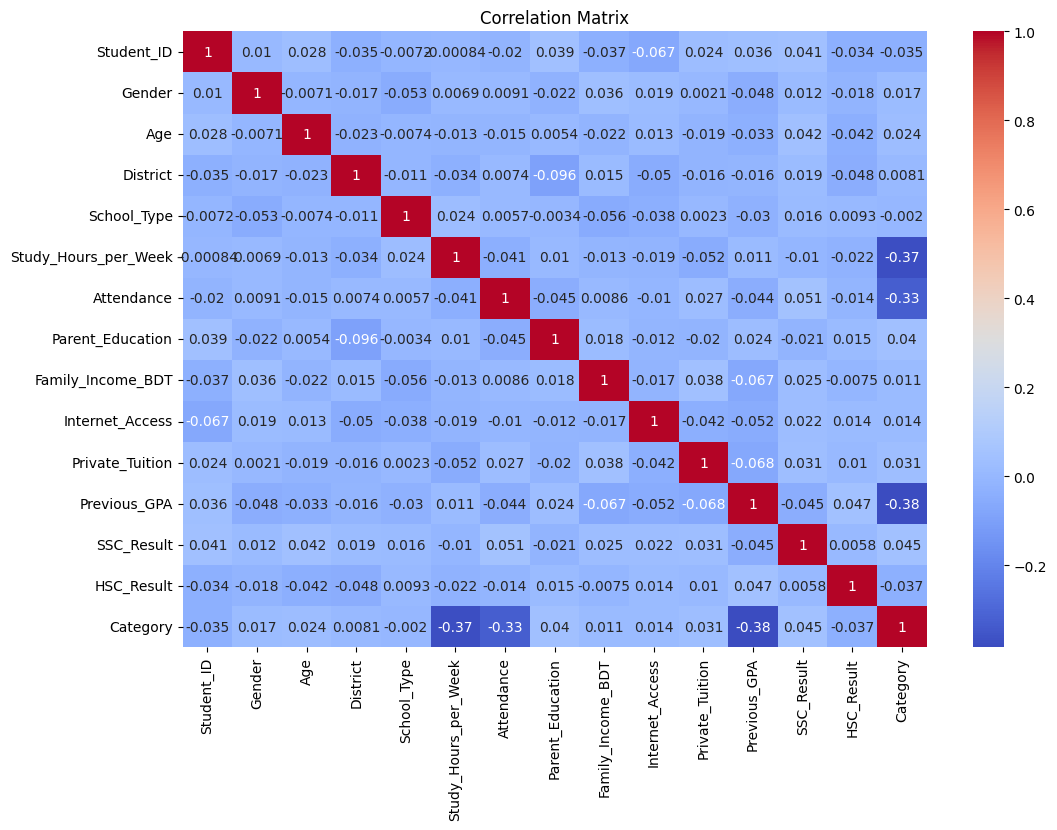

In [55]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [58]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler


new_student_data = {
    'Gender': ['Male'],
    'Age': [16],
    'District': ['Dhaka'],
    'School_Type': ['Public'],
    'Study_Hours_per_Week': [15],
    'Attendance': [85],
    'Parent_Education': ['Graduate'],
    'Family_Income_BDT': [60000],
    'Internet_Access': ['Yes'],
    'Private_Tuition': ['No'],
    'Previous_GPA': [4.0], # Added to match training features
    'SSC_Result': [4.0],   # Added to match training features
    'HSC_Result': [4.0]    # Added to match training features
}

new_student_df = pd.DataFrame(new_student_data)
display("New student raw data:", new_student_df)

# Load the original raw data to correctly fit LabelEncoders for categorical features
df_raw = pd.read_csv('bangladesh_student_performance.csv')

# Store individual LabelEncoders for each categorical column
label_encoders = {}
for col in df_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    le.fit(df_raw[col]) # Fit on original raw data
    label_encoders[col] = le
    # Transform the new_student_df's categorical columns using the fitted encoders
    if col in new_student_df.columns:
        new_student_df[col] = label_encoders[col].transform(new_student_df[col])

# Create and fit LabelEncoder for the target 'Category' for inverse transformation
# The 'Category' values are 'A', 'B', 'C'
le_target = LabelEncoder()
le_target.fit(['A', 'B', 'C'])

# Ensure the columns in new_student_df match the order of features used for training (X)
# X is a global variable from the notebook execution that holds the training feature DataFrame
feature_columns_order = X.columns.tolist()

# Reorder new_student_df columns to match the training data
new_student_df = new_student_df[feature_columns_order]

# Scale the entire new_student_df using the already fitted scaler
new_student_scaled = scaler.transform(new_student_df)

display("New student preprocessed data:", pd.DataFrame(new_student_scaled, columns=feature_columns_order))

# Make prediction using the trained SVM model
predicted_category_encoded = svm.predict(new_student_scaled)

predicted_category_label = le_target.inverse_transform(predicted_category_encoded)

print(f"\nPredicted Performance Category: {predicted_category_label[0]} ({le_target.classes_[predicted_category_encoded[0]]})\n")

'New student raw data:'

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result
0,Male,16,Dhaka,Public,15,85,Graduate,60000,Yes,No,4.0,4.0,4.0


'New student preprocessed data:'

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result
0,1.022759,-0.380617,-0.619765,1.048684,-0.288139,0.510596,-1.292754,1.732529,1.043443,-0.980196,0.021822,-0.609485,-0.018008



Predicted Performance Category: C (C)

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


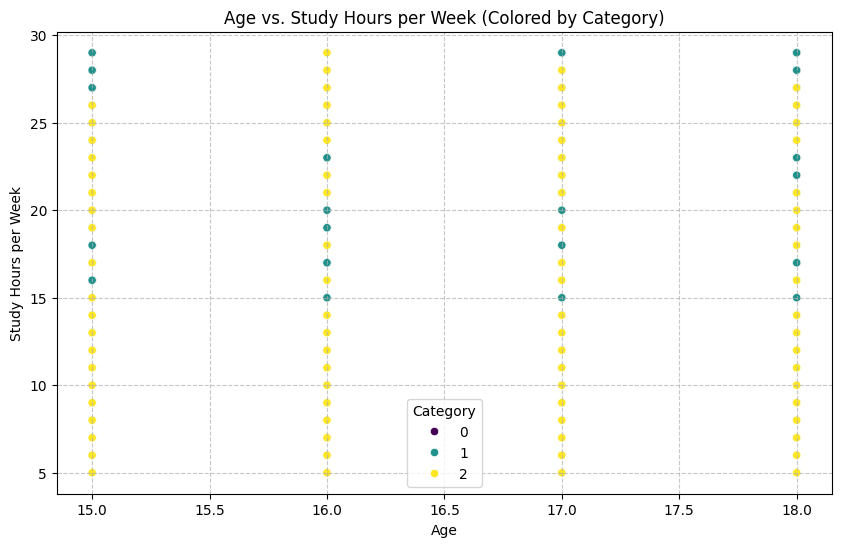

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Study_Hours_per_Week', data=df, hue='Category', palette='viridis')
plt.title('Age vs. Study Hours per Week (Colored by Category)')
plt.xlabel('Age')
plt.ylabel('Study Hours per Week')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()